Launch radius r0 = 6.05e+14 cm
Terminal velocity v_inf = 30000 km / s
Line locking maintained between ~0 km / s-10200.145520845044 km / s km/s


/opt/anaconda3/envs/LineLocking/lib/python3.12/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


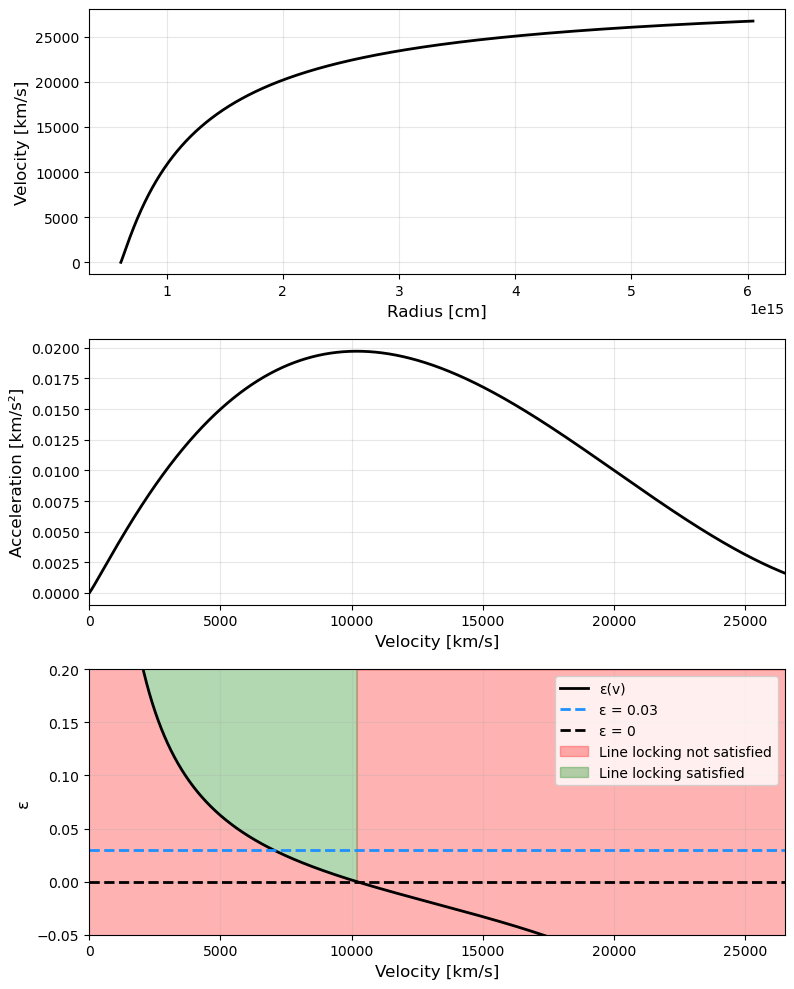

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

# Constants
M_sun = 1.989e33*u.gram  # grams
c = 2.998e10*u.cm/u.s  # cm/s
G = 6.674e-8*u.cm**3/u.gram/u.s**2  # cm^3 g^-1 s^-2
sigma_T = 6.652e-25*u.cm**2  # cm^2
m_p = 1.673e-24*u.gram  # grams

# Fiducial parameters
M_bh = 1e8 * M_sun  # Black hole mass
L_bol = 1e46*u.erg/u.s  # erg/s
alpha = 0.5  # CAK parameter
beta = 1.1  # Velocity beta law

# Calculate Eddington ratio
Gamma_Edd = ((sigma_T * L_bol) / (4 * np.pi * m_p * c * G * M_bh)).to(u.dimensionless_unscaled)


# Find launch radius for v_inf = 30,000 km/s
v_inf_target = 30000*u.km/u.s
r0 = ((2 * G * M_bh * (1 - Gamma_Edd) * alpha / (1 - alpha)) / v_inf_target**(2)).to(u.cm)
print(f"Launch radius r0 = {r0:.2e}")

v_inf = v_inf_target
print(f"Terminal velocity v_inf = {v_inf:.0f}")

# Velocity as a function of radius (Equation 62)
def velocity(r, r0, v_inf):
    x = r / r0
    return v_inf * (1 - 1/x)**beta

# Acceleration as a function of velocity (from Equation 61)
def acceleration(v):
    return (v**2*beta/r0)*(v_inf/v)**(1/beta)*(1-(v/v_inf)**(1/beta))**2

# Calculate epsilon (Equation 64)
def calculate_epsilon(v, delta_v=497/2*u.km/u.s):  # delta_v in cm/s (half of 497 km/s)
    # Get accelerations at v - delta and v + delta
    a1 = acceleration(v - delta_v)
    a2 = acceleration(v + delta_v)
    
    epsilon = (a2 - a1) / np.abs(a2)
    return epsilon

# Create figure
ylim=0.2
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Panel 1: Velocity vs Radius
r_range = np.logspace(np.log10(r0.value*1.001), np.log10(r0.value*10), 100000)*u.cm
v_range = velocity(r_range, r0, v_inf)

axes[0].plot(r_range.to(u.cm), v_range.to(u.km/u.s), 'k-', linewidth=2)
axes[0].set_xlabel('Radius [cm]', fontsize=12)
axes[0].set_ylabel('Velocity [km/s]', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Panel 2: Acceleration vs Velocity
a_plot = acceleration(v_range)

axes[1].plot(v_range.to(u.km/u.s), a_plot.to(u.km/u.s/u.s), 'k-', linewidth=2)
axes[1].set_xlabel('Velocity [km/s]', fontsize=12)
axes[1].set_ylabel('Acceleration [km/s²]', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Panel 3: Epsilon vs Velocity with line locking condition
epsilon_vals = calculate_epsilon(v_range)
epsilon_vals_cleaned = epsilon_vals[~np.isnan(epsilon_vals)]
v_range_adjusted = v_range[~np.isnan(epsilon_vals)]

axes[2].plot(v_range_adjusted.to(u.km/u.s), epsilon_vals_cleaned.to(u.dimensionless_unscaled), 'k-', linewidth=2, label='ε(v)')

# Add horizontal line for estimated epsilon value (from paper)
epsilon_estimated = 0.03  # From Section 6
axes[2].axhline(epsilon_estimated, color='dodgerblue', linestyle='--', linewidth=2, 
                label=f'ε = {epsilon_estimated}')
axes[2].axhline(0, color='black', linestyle='--', linewidth=2, 
                label=f'ε = 0')

# Color regions: green where line locking condition is satisfied
extra_x = np.linspace(-1e1, v_range_adjusted.value.min(), 100)   # create new x block
extra_eps = np.full_like(extra_x, epsilon_vals_cleaned[0])  # extend flat or choose value
v_extended = np.concatenate([extra_x*u.km/u.s, v_range_adjusted.to(u.km/u.s)])
eps_extended = np.concatenate([extra_eps, epsilon_vals_cleaned])
axes[2].fill_between(v_extended.to(u.km/u.s).value, -ylim, eps_extended,
                     alpha=0.3, color='red', label='Line locking not satisfied')
x_cross_idx = idx = np.argmin(np.abs(epsilon_vals_cleaned))
axes[2].fill_between(v_range_adjusted[x_cross_idx:].to(u.km/u.s).value, epsilon_vals_cleaned[x_cross_idx:], ylim, 
                      alpha=0.3, color='red')
axes[2].fill_between(v_range_adjusted[:x_cross_idx].to(u.km/u.s).value, epsilon_vals_cleaned[:x_cross_idx], ylim,
                      alpha=0.3, color='green', label='Line locking satisfied')


axes[2].set_xlabel('Velocity [km/s]', fontsize=12)
axes[2].set_ylabel('ε', fontsize=12)
# axes[2].set_xlim(0, 25000)
axes[2].set_ylim(-0.05, ylim)
axes[2].set_xlim(0, 26500)
axes[1].set_xlim(0, 26500)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

# Find where epsilon crosses threshold
crossing_idx = np.where(np.diff(np.sign(epsilon_vals - epsilon_estimated)))[0]
if len(crossing_idx) > 0:
    v_crossing = v_range[crossing_idx[-1]] / 1e5
    print(f"Line locking maintained between ~{v_crossing.to(u.km/u.s):.0f}-{v_range_adjusted[x_cross_idx].to(u.km/u.s)} km/s")

plt.tight_layout()
plt.savefig("Results/Figures/Wind_Dynamics.png", bbox_inches="tight", dpi=300)
plt.show()